In [1]:
!pip install -q kagglehub

In [2]:
import pandas as pd
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns

In [3]:
base = kagglehub.dataset_download("menegidio/fishmorph-dataset")
print(os.listdir(base))

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.
['FISHMORPH_Order_Dataset.csv', 'FISHMORPH_Family_Dataset.csv']


In [4]:
df = pd.read_csv(os.path.join(base, 'FISHMORPH_Order_Dataset.csv'))
df.head()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cypriniformes
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Perciformes
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cypriniformes
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cypriniformes
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cypriniformes


In [5]:
df.describe()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt
count,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000
mean,22.004517,4.452438,0.549087,0.391665,0.381768,0.399786,0.571818,0.285316,0.189343,2.560795
std,33.612007,2.338235,0.094883,0.132814,0.194352,0.302658,0.117486,0.155629,0.056109,1.016659
min,1.200000,1.033084,0.159248,0.000000,0.000000,0.000000,0.224525,0.000000,0.000000,0.000000
25%,7.000000,3.139102,0.487993,0.293205,0.278014,0.257999,0.490052,0.193134,0.157972,1.999744
50%,12.600000,4.038851,0.546213,0.389429,0.406904,0.361436,0.564739,0.275039,0.183497,2.436329
75%,24.500000,5.002621,0.605125,0.486221,0.516001,0.490671,0.648039,0.368876,0.215031,2.919818
max,800.000000,43.728161,1.000000,1.026667,1.026316,7.060344,1.230105,0.857097,0.511113,15.452061


In [21]:
df = df.groupby('Order').filter(lambda x: len(x) >= 5)

In [6]:
print("Total de duplicados:", df.duplicated().sum())
df[df.duplicated(keep=False)]

Total de duplicados: 1


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
2346,45.0,9.913631,0.554642,0.192969,0.248817,0.287949,0.550752,0.320721,0.0,0.0,Pleuronectiformes
2349,45.0,9.913631,0.554642,0.192969,0.248817,0.287949,0.550752,0.320721,0.0,0.0,Pleuronectiformes


In [7]:
print(df.dtypes)

MBl      float64
BEl      float64
VEp      float64
REs      float64
OGp      float64
RMl      float64
BLs      float64
PFv      float64
PFs      float64
CPt      float64
Order     object
dtype: object


In [8]:
print(df.isnull().sum())

MBl      0
BEl      0
VEp      0
REs      0
OGp      0
RMl      0
BLs      0
PFv      0
PFs      0
CPt      0
Order    0
dtype: int64


In [9]:
le = LabelEncoder()
df['Order_Rev'] = le.fit_transform(df['Order'])

In [11]:
x = df.drop(columns=['Order', 'Order_Rev']).select_dtypes(include=['number'])
print(x)

        MBl       BEl       VEp       REs       OGp       RMl       BLs  \
0     130.0  4.579113  0.622642  0.375019  0.622642  0.868659  0.484981   
1      11.5  2.796068  0.650700  0.353780  0.509800  0.411157  0.722461   
2       6.6  4.564329  0.518187  0.312002  0.203985  0.413221  0.591495   
3      10.9  4.390422  0.548247  0.244804  0.168959  0.324728  0.642991   
4      18.9  4.410271  0.542353  0.292058  0.183790  0.398567  0.685672   
...     ...       ...       ...       ...       ...       ...       ...   
8337   22.0  8.160515  0.742393  0.394320  0.307719  0.332283  0.793826   
8338   50.0  5.241134  0.600061  0.377792  0.293883  0.301585  0.617588   
8339    4.0  3.159920  0.453558  0.560501  0.533168  0.175106  0.470270   
8340  140.0  4.165031  0.545773  0.115646  0.471200  0.483810  0.498305   
8341  140.0  4.420704  0.600544  0.145919  0.422607  0.458131  0.476710   

           PFv       PFs       CPt  
0     0.273585  0.144108  3.348991  
1     0.330169  0.221095 

In [12]:
y = df['Order_Rev']
print(y)

0        8
1       22
2        8
3        8
4        8
        ..
8337    22
8338    22
8339     9
8340    28
8341    28
Name: Order_Rev, Length: 8342, dtype: int64


In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [14]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

In [18]:
param_grid = {
    'svc__C': [0.01, 0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto']
}

In [22]:
grid = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='accuracy', verbose=3, n_jobs=-1
)

In [23]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC())]),
             n_jobs=-1,
             param_grid={'svc__C': [0.01, 0.1, 1, 10],
                         'svc__gamma': ['scale', 'auto'],
                         'svc__kernel': ['linear', 'rbf']},
             scoring='accuracy', verbose=3)

In [24]:
best_score = grid.best_score_
best_params = grid.best_params_
best_model = grid.best_estimator_
y_best = best_model.predict(x_test)
best_accuracy = accuracy_score(y_test, y_best)
print(best_score)
print(best_params)
print(best_model)


0.7928968100219553
{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(C=10))])


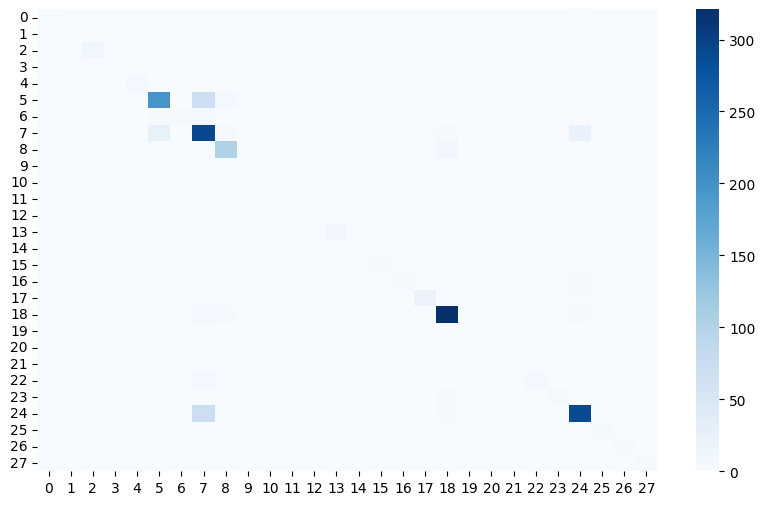

In [25]:
matriz = confusion_matrix(y_test, y_best)

plt.figure(figsize=(10,6))
sns.heatmap(matriz, cmap='Blues'
            )
plt.show()